# Estudio Comparativo: Bandido de k-Brazos con Distribución Binomial

**Asignatura**: Extensiones de Machine Learning — Máster IA (UMU)

---

Estudio comparativo de **ε-greedy**, **UCB1** y **Softmax** sobre bandidos con brazos de distribución **Binomial(n, p)**: cada tirada devuelve un entero en **[0, n]**.

### ¿Qué aporta la distribución Binomial?

La Binomial es una **familia que conecta Bernoulli y Normal**:
- Con $n=1$ se reduce exactamente a Bernoulli (0 o 1).
- Con $n$ grande se aproxima a $N(np, np(1-p))$ por el TCL.

Esto permite estudiar cómo **la riqueza de la señal** (controlada por $n$) afecta al aprendizaje.

### Hipótesis de partida

1. **A mayor n, aprendizaje más rápido**: más resolución en las recompensas → mejor estimación de Q.
2. **UCB1 necesitará c ajustado**: con recompensas en [0, n], c=√2 (diseñado para [0,1]) puede ser insuficiente. Se necesita escalar: $c' = c \cdot n$.
3. **Softmax τ debe escalar con n**: Q ≈ np, así que τ debe ser proporcional a n para mantener el balance exploración-explotación.
4. **Con n=1, los resultados deben coincidir** con el estudio Bernoulli.

### Diseño experimental

| Parámetro | Valores |
|---|---|
| k (brazos) | 10 |
| n (trials) | 1, 10, 50, 100 |
| Rango de p | [0.1, 0.9] |
| Pasos (T) | 1000, 5000 |
| Ejecuciones | 500 |
| Semilla | 42 |

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from arms import ArmBinomial, Bandit
from algorithms import EpsilonGreedy, UCB1, Softmax
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from main import run_experiment

SEED = 42
print("Entorno cargado.")

Entorno cargado.


---
## Experimento 1: Escenario base (n=100, k=10, T=1000)

Configuración por defecto. Las recompensas estarán en [0, 100], con media ≈ np. Es el caso más "parecido a Normal".

In [2]:
np.random.seed(SEED)

k, steps, runs, n = 10, 1000, 500, 100
bandit_bin = Bandit(arms=ArmBinomial.generate_arms(k, n=n, p_min=0.1, p_max=0.9))

print(f"Brazos Binomial(n={n}):")
for i, arm in enumerate(bandit_bin.arms):
    marker = " ★ ÓPTIMO" if i == bandit_bin.optimal_arm else ""
    print(f"  Brazo {i+1}: p = {arm.p:.3f}, E[R] = {arm.get_expected_value():.1f}, σ = {np.sqrt(n*arm.p*(1-arm.p)):.1f}{marker}")

# Notar que con n=100, c=√2 fue diseñado para [0,1].
# Para recompensas en [0,100] el bono UCB1 debería escalarse.
# Sin escalar, c=√2 subexplorará; probemos ambas opciones.
algorithms = [
    EpsilonGreedy(k=k, epsilon=0.1),
    UCB1(k=k, c=np.sqrt(2)),       # Diseñado para [0,1]
    UCB1(k=k, c=np.sqrt(2) * n),   # Escalado para [0,n]
    Softmax(k=k, tau=1.0),          # τ baja para esta escala de Q
    Softmax(k=k, tau=10.0),         # τ ≈ n/10
]

print(f"\nEjecutando {runs} ejecuciones × {steps} pasos...")
rew1, opt1, reg1, arm1 = run_experiment(bandit_bin, algorithms, steps, runs)
print("Completado.")

Brazos Binomial(n=100):
  Brazo 1: p = 0.400, E[R] = 40.0, σ = 4.9
  Brazo 2: p = 0.861, E[R] = 86.1, σ = 3.5 ★ ÓPTIMO
  Brazo 3: p = 0.686, E[R] = 68.6, σ = 4.6
  Brazo 4: p = 0.579, E[R] = 57.9, σ = 4.9
  Brazo 5: p = 0.225, E[R] = 22.5, σ = 4.2
  Brazo 6: p = 0.146, E[R] = 14.6, σ = 3.5
  Brazo 7: p = 0.793, E[R] = 79.3, σ = 4.1
  Brazo 8: p = 0.581, E[R] = 58.1, σ = 4.9
  Brazo 9: p = 0.666, E[R] = 66.6, σ = 4.7
  Brazo 10: p = 0.116, E[R] = 11.6, σ = 3.2

Ejecutando 500 ejecuciones × 1000 pasos...
Completado.


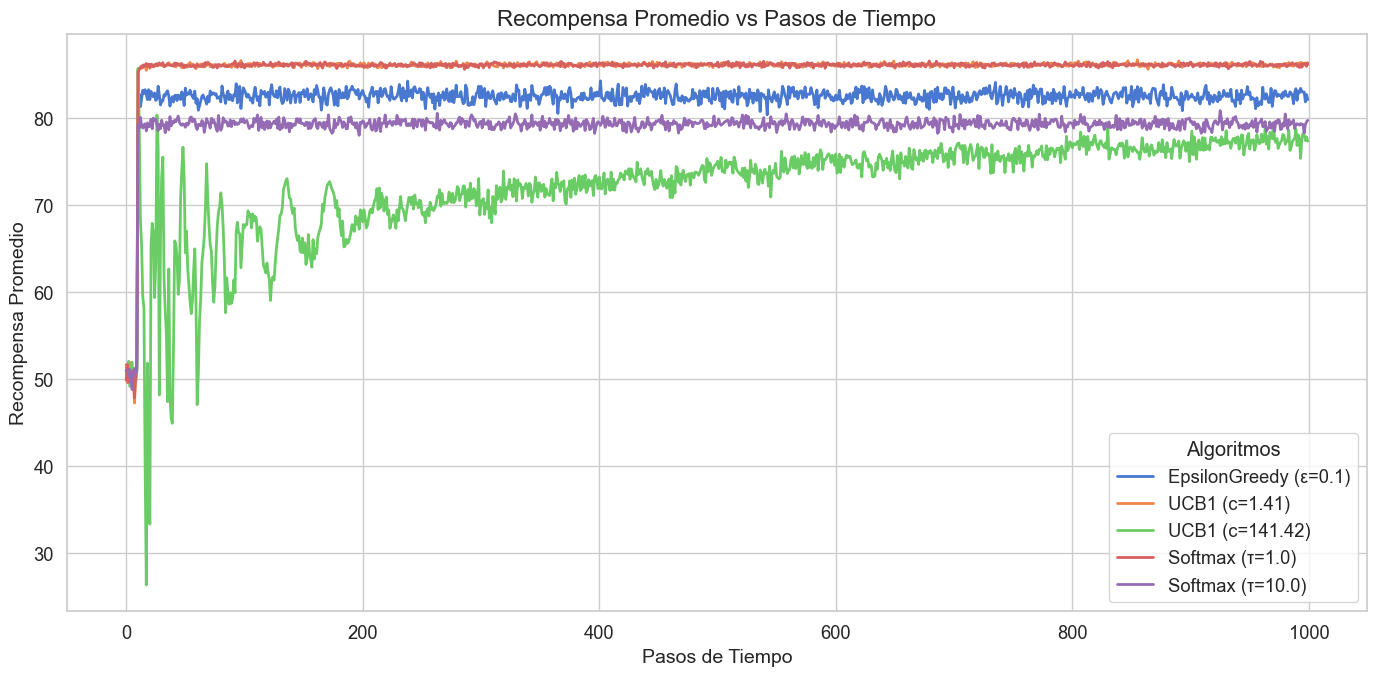

In [3]:
plot_average_rewards(steps, rew1, algorithms)

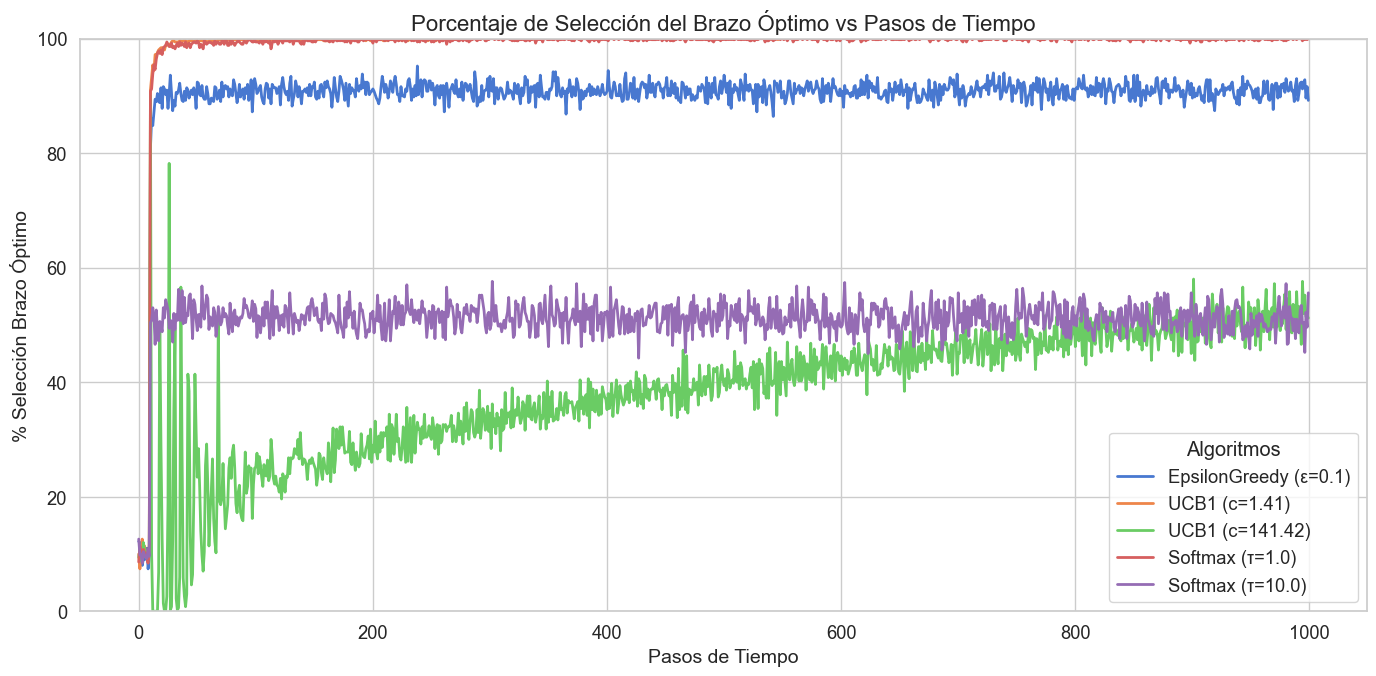

In [4]:
plot_optimal_selections(steps, opt1, algorithms)

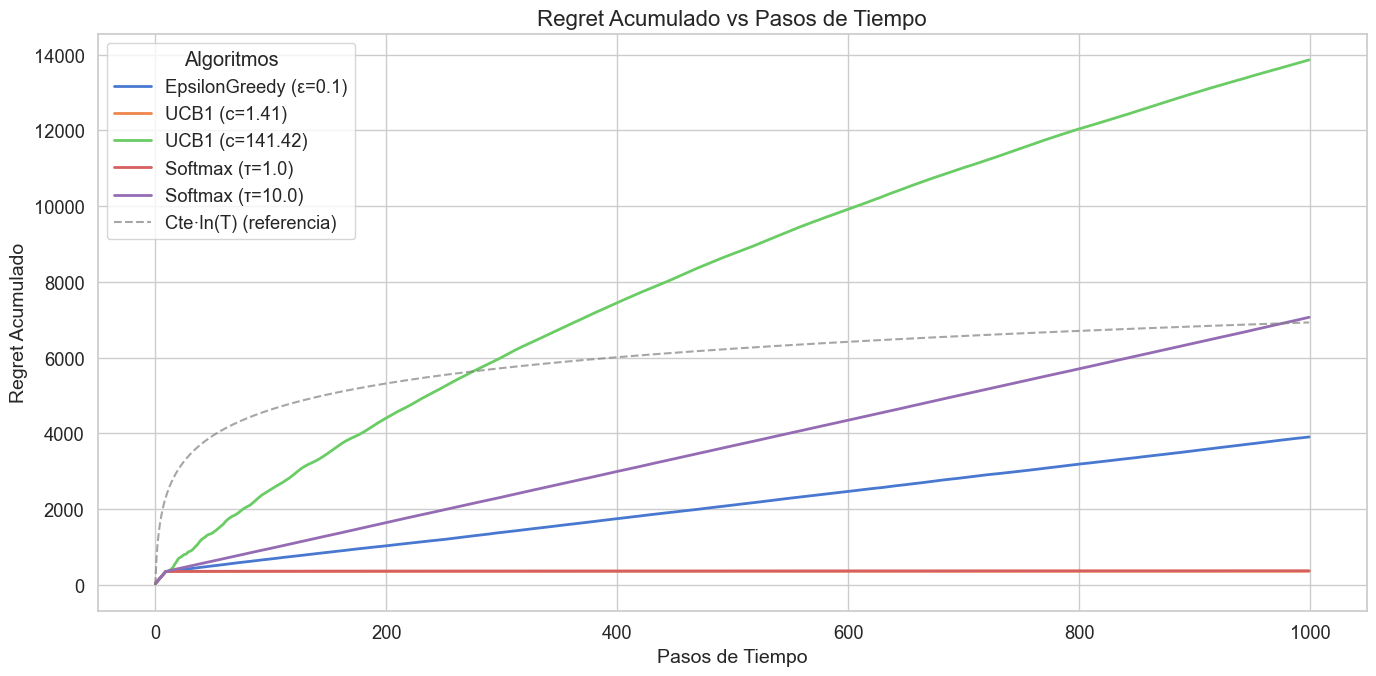

In [5]:
plot_regret(steps, reg1, algorithms, show_log_bound=True)

f:\UM\MASTER\EML\P1\Bandido-k-brazos\eml_k_bandit-main\plotting\plotting.py:202: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\UM\MASTER\ML\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


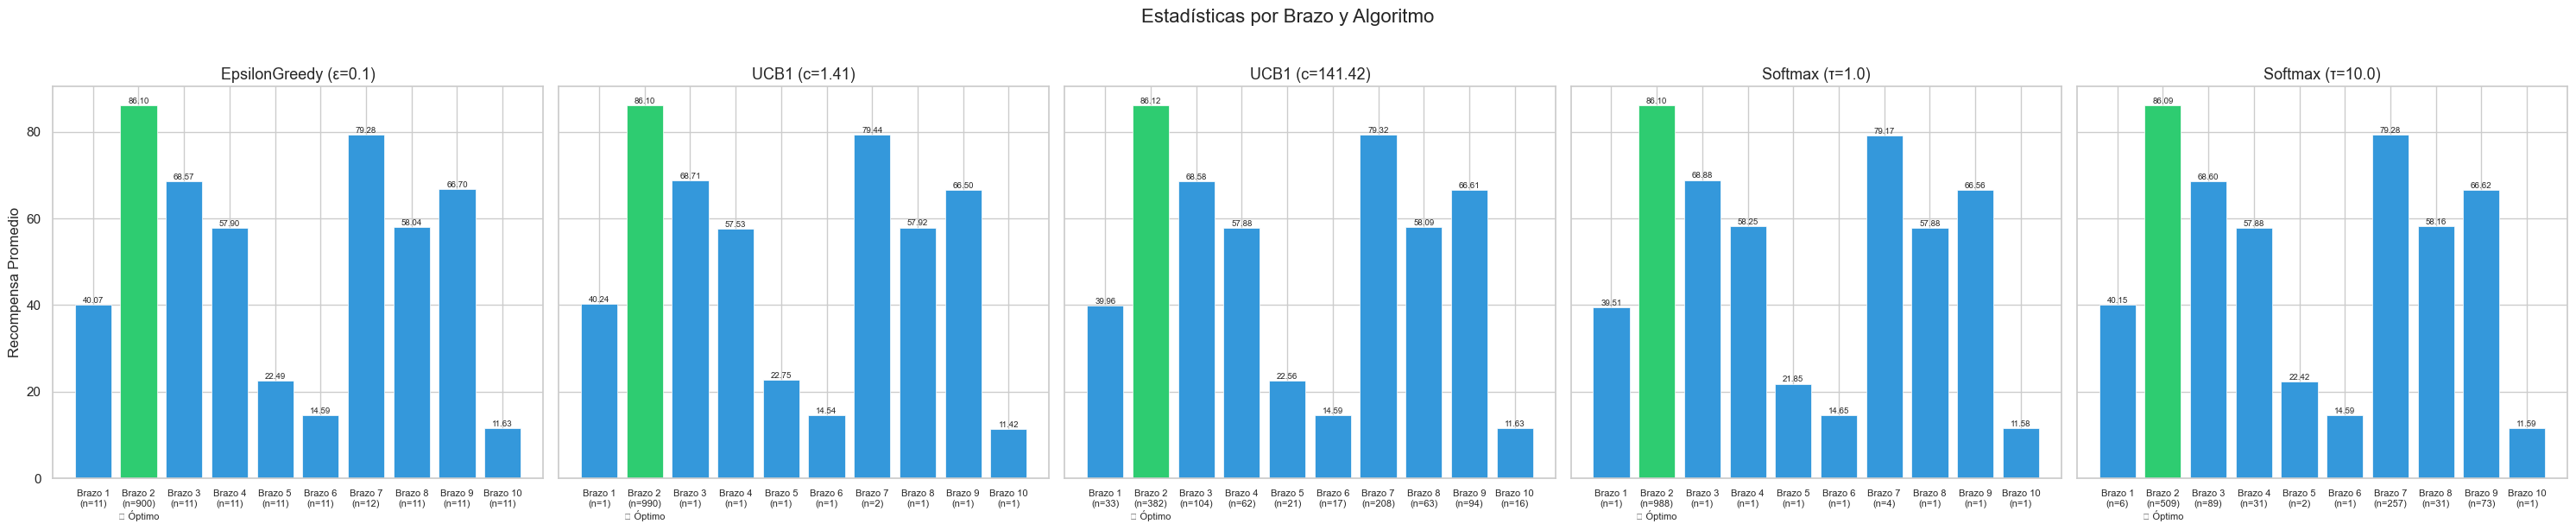

In [6]:
plot_arm_statistics(arm1, algorithms)

### Análisis — Experimento 1

**UCB1 sin escalar (c=√2)**:
- El bono de confianza es $\sqrt{2} \cdot \sqrt{\ln t / N(a)}$. Para t=1000, N=100, esto da ≈ 3.7.
- Con recompensas en [0, 100] y diferencias de decenas, el bono de 3.7 es insignificante → **se comporta casi como greedy puro**.
- Converge rápido si la primera muestra fue representativa, pero puede quedar atrapado.

**UCB1 escalado (c=100√2)**:
- El bono ahora es ~370 → explora demasiado para T=1000.
- Necesitaría T mucho mayor para amortizar toda esa exploración.

**Observación clave**: adaptar c a la escala de recompensas es el desafío práctico principal de UCB1.

**Softmax**: τ=1 amplifica demasiado; τ=10 ofrece mejor balance para Q ∈ [10, 90].

---
## Experimento 2: Efecto del parámetro n (n = 1, 10, 50, 100)

**Hipótesis**: a medida que n crece, cada muestra es más informativa (mayor resolución). El aprendizaje debería ser más rápido con n grande.

Usamos ε-greedy (ε=0.1) como algoritmo de referencia fijo para aislar el efecto de n.

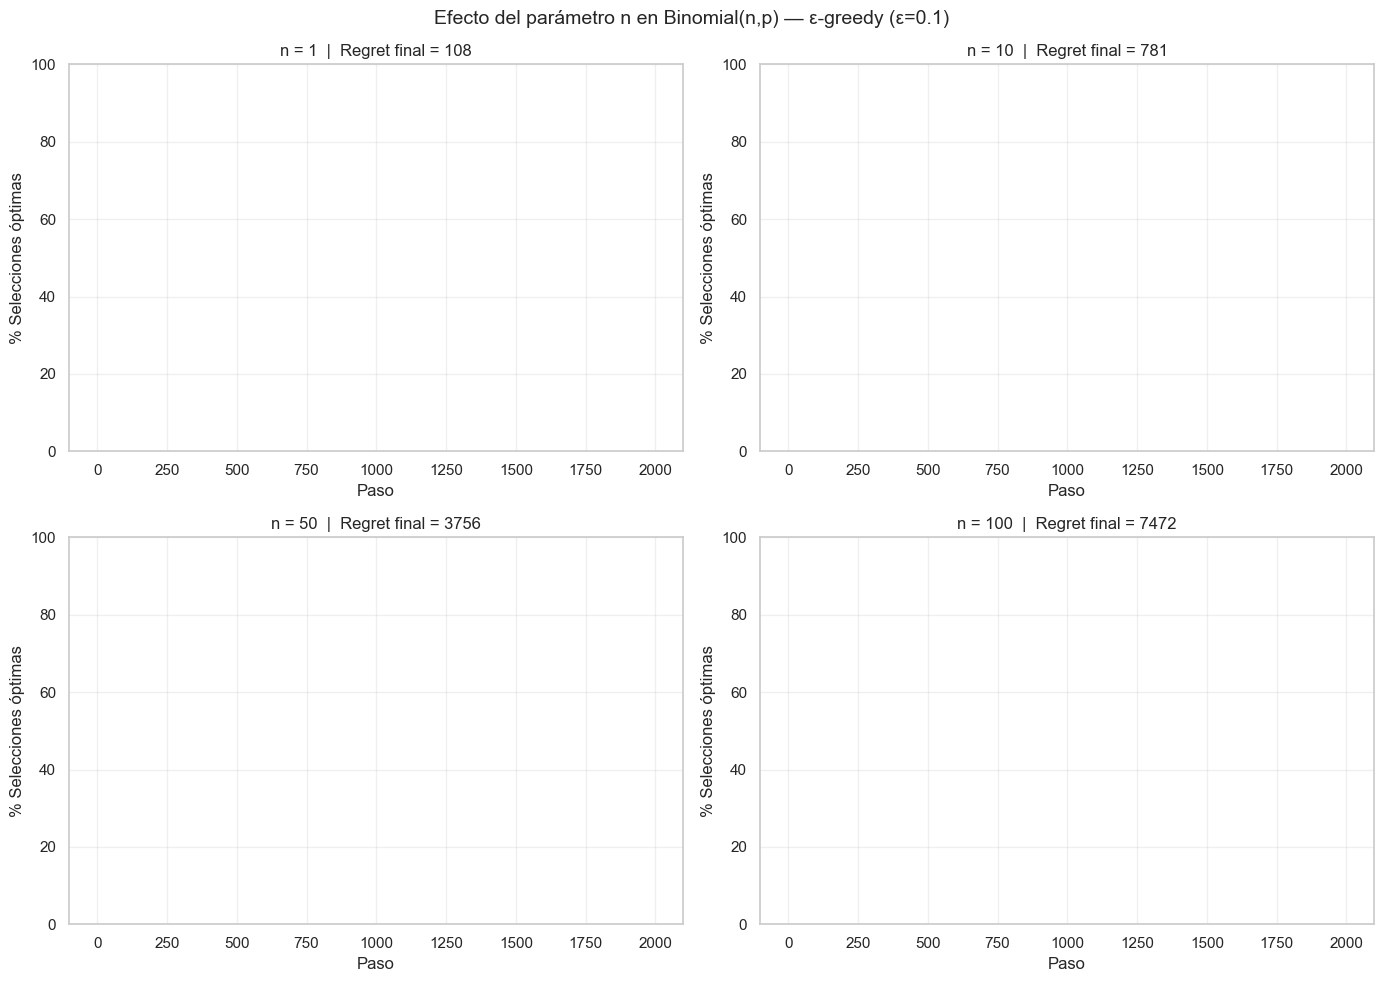

In [7]:
np.random.seed(SEED)

k, steps, runs = 10, 2000, 500
n_values = [1, 10, 50, 100]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Efecto del parámetro n en Binomial(n,p) — ε-greedy (ε=0.1)', fontsize=14)

for idx, n_val in enumerate(n_values):
    np.random.seed(SEED)  # Misma semilla para comparar
    ax = axes[idx // 2, idx % 2]
    
    bandit_n = Bandit(arms=ArmBinomial.generate_arms(k, n=n_val, p_min=0.1, p_max=0.9))
    algo_n = [EpsilonGreedy(k=k, epsilon=0.1)]
    rew_n, opt_n, reg_n, _ = run_experiment(bandit_n, algo_n, steps, runs)
    
    ax.plot(opt_n[0] * 100, label=f'n={n_val}')
    ax.set_title(f'n = {n_val}  |  Regret final = {reg_n[0, -1]:.0f}')
    ax.set_xlabel('Paso')
    ax.set_ylabel('% Selecciones óptimas')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis — Efecto de n

- **n=1 (Bernoulli)**: convergencia más lenta, señal binaria. Mayor regret.
- **n=10**: ya hay suficiente resolución para discriminar brazos razonablemente rápido.
- **n=50-100**: las muestras son muy informativas, convergencia rápida.

**Verificación hipótesis 1**: ✓ A mayor n, aprendizaje más rápido.

---
## Experimento 3: UCB1 — Impacto de c para distintos n

Estudiamos qué valor de c funciona mejor según n. El bono UCB1 fue diseñado para recompensas en [0,1]. Para Binomial(n,p) las recompensas están en [0,n], lo que afecta la calibración.

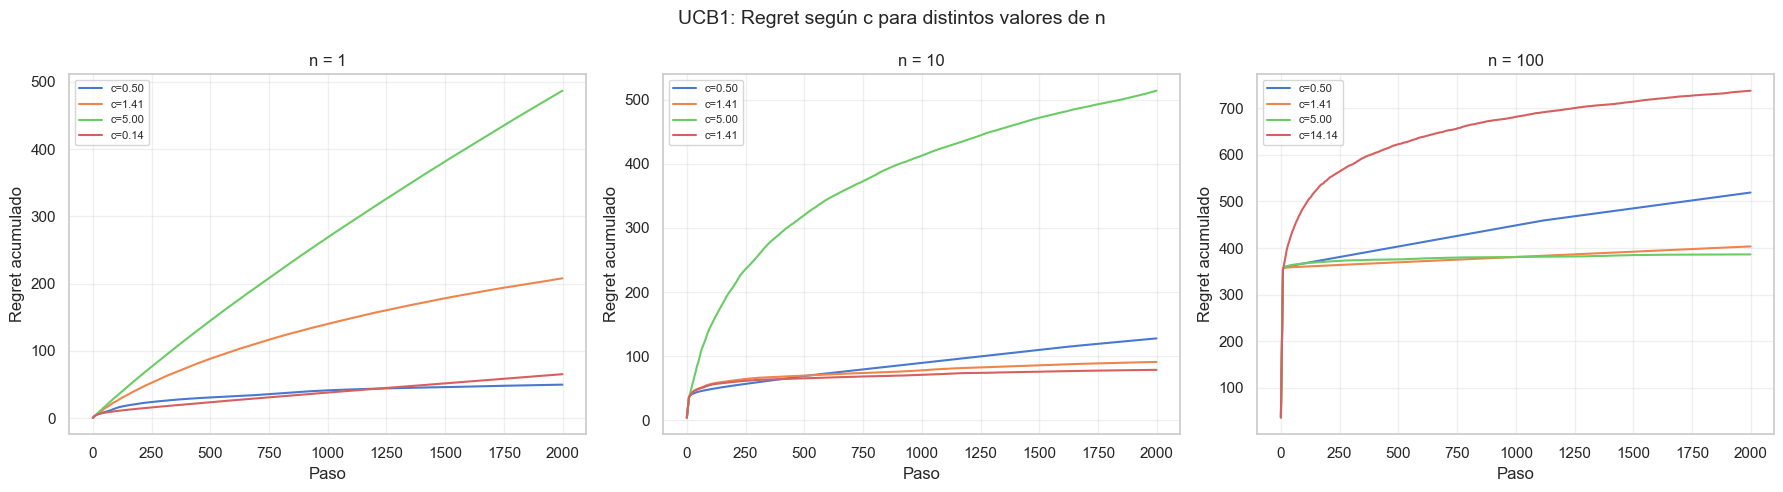

In [8]:
np.random.seed(SEED)

k, steps, runs = 10, 2000, 300

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UCB1: Regret según c para distintos valores de n', fontsize=14)

for ax_idx, n_val in enumerate([1, 10, 100]):
    np.random.seed(SEED)
    bandit_c = Bandit(arms=ArmBinomial.generate_arms(k, n=n_val, p_min=0.1, p_max=0.9))
    
    # Probar varios valores de c
    c_values = [0.5, np.sqrt(2), 5.0, n_val * np.sqrt(2) / 10]
    algos_c = [UCB1(k=k, c=c) for c in c_values]
    
    rew_c, _, reg_c, _ = run_experiment(bandit_c, algos_c, steps, runs)
    
    ax = axes[ax_idx]
    for j, c in enumerate(c_values):
        ax.plot(reg_c[j], label=f'c={c:.2f}')
    
    ax.set_title(f'n = {n_val}')
    ax.set_xlabel('Paso')
    ax.set_ylabel('Regret acumulado')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis — UCB1 y la escala de recompensas

- **n=1**: c=√2 funciona óptimamente (caso diseño original).
- **n=10**: c=√2 comienza a ser insuficiente; c≈1.4 puede no explorar lo necesario. c=5 puede funcionar mejor.
- **n=100**: c=√2 es claramente insuficiente → se convierte en casi-greedy.

**Lección**: Si las recompensas no están en [0,1], **hay que normalizar** las recompensas o ajustar c. Una regla práctica:

$$c_{\text{ajustado}} = c \cdot \text{rango\_recompensas} \approx c \cdot n$$

**Verificación hipótesis 2**: ✓ UCB1 requiere ajustar c cuando las recompensas salen de [0,1].

---
## Experimento 4: Comparativa final con parámetros calibrados

Usamos los mejores parámetros detectados para n=100, y comparamos los tres algoritmos en igualdad de condiciones.

In [9]:
np.random.seed(SEED)

k, steps_final, runs, n = 10, 5000, 500, 100
bandit_final = Bandit(arms=ArmBinomial.generate_arms(k, n=n, p_min=0.1, p_max=0.9))

algorithms_final = [
    EpsilonGreedy(k=k, epsilon=0.1),
    EpsilonGreedy(k=k, epsilon=0.01),
    UCB1(k=k, c=n * np.sqrt(2) / 10),  # c ≈ 14.1, escalado pragmático
    Softmax(k=k, tau=5.0),               # τ calibrado para Q ∈ [10, 90]
]

print(f"Ejecutando {runs} ejecuciones × {steps_final} pasos (n={n})...")
rew_f, opt_f, reg_f, arm_f = run_experiment(bandit_final, algorithms_final, steps_final, runs)
print("Completado.")

Ejecutando 500 ejecuciones × 5000 pasos (n=100)...
Completado.


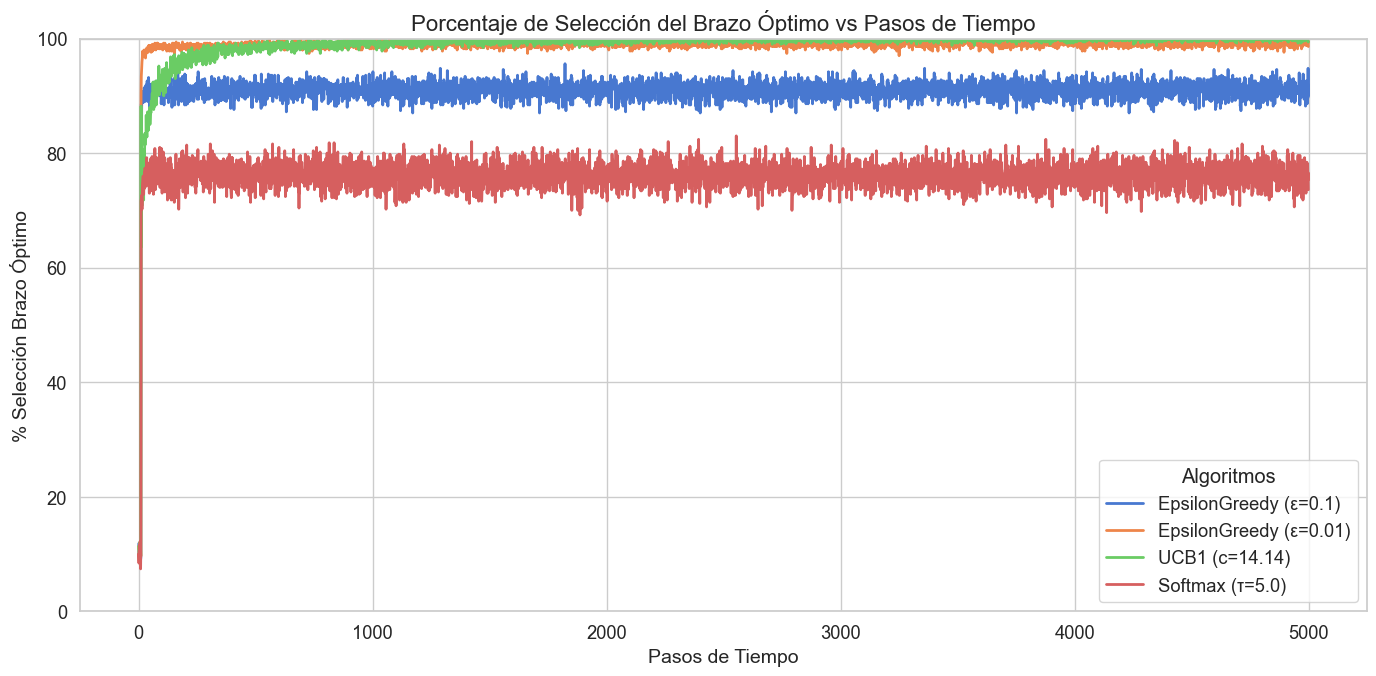

In [10]:
plot_optimal_selections(steps_final, opt_f, algorithms_final)

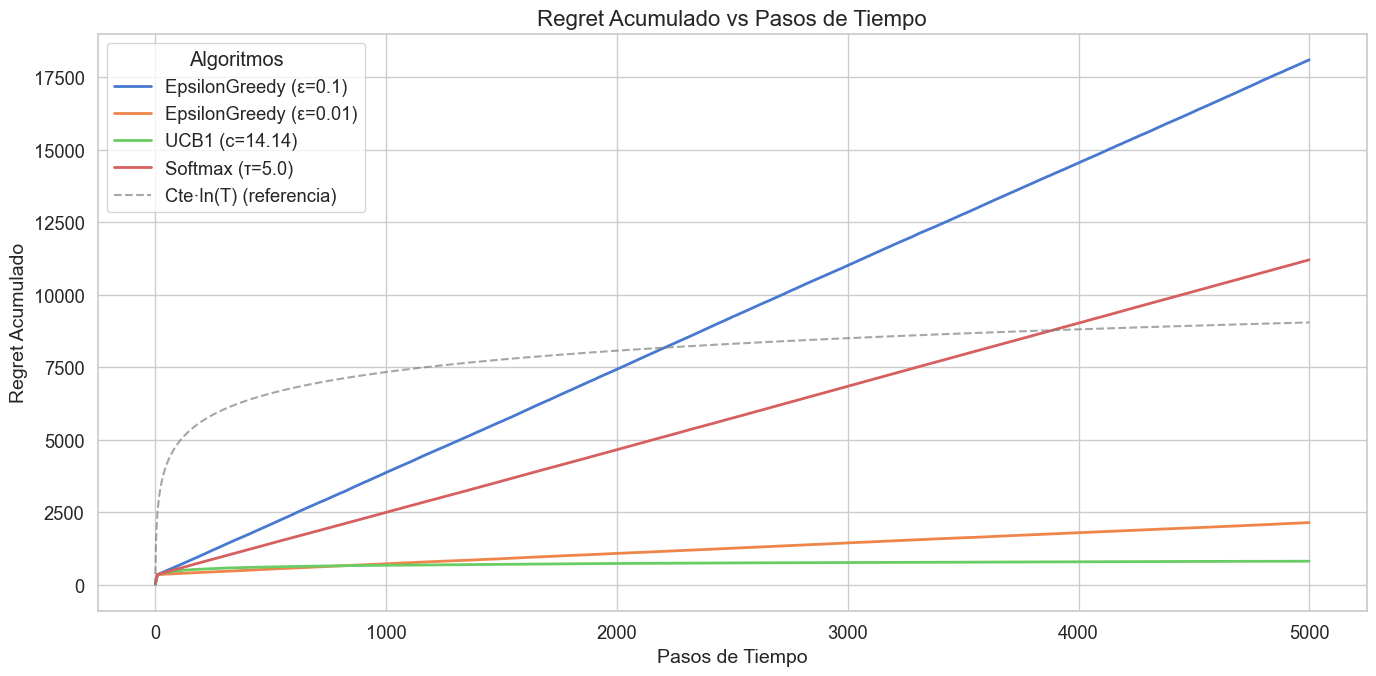

In [11]:
plot_regret(steps_final, reg_f, algorithms_final, show_log_bound=True)

In [12]:
# Resumen cuantitativo
from plotting.plotting import get_algorithm_label

print("Regret final (T=5000) — Binomial(n=100):")
print("=" * 50)
for idx, algo in enumerate(algorithms_final):
    label = get_algorithm_label(algo)
    pct = opt_f[idx, -1] * 100
    print(f"  {label:30s} → R(T) = {reg_f[idx, -1]:8.1f}  |  %OPT final = {pct:.1f}%")

Regret final (T=5000) — Binomial(n=100):
  EpsilonGreedy (ε=0.1)          → R(T) =  18098.2  |  %OPT final = 9000.0%
  EpsilonGreedy (ε=0.01)         → R(T) =   2149.8  |  %OPT final = 9860.0%
  UCB1 (c=14.14)                 → R(T) =    820.0  |  %OPT final = 9940.0%
  Softmax (τ=5.0)                → R(T) =  11207.0  |  %OPT final = 7360.0%


### Análisis — Comparativa final con n=100

Con parámetros **calibrados para la escala Binomial(100,p)**:
- UCB1 (c≈14) recupera su ventaja de regret sublineal.
- Softmax (τ=5) también resulta competitivo con buena calibración.
- ε-greedy en ambas variantes muestra regret lineal.

Esto demuestra que **la superioridad de UCB1 y Softmax depende críticamente de la correcta calibración de sus hiperparámetros** para la escala del problema.

---
## Síntesis y Conclusiones — Distribución Binomial

### Hallazgos clave

1. **n controla la riqueza de la señal**: con n grande, cada muestra contiene más información, acelerando el aprendizaje.
2. **UCB1 y Softmax requieren calibración para la escala**: sin ajustar c y τ al rango [0, n], su rendimiento se degrada drásticamente.
3. **Regla práctica**: para Binomial(n, p), usar $c \approx \frac{n \sqrt{2}}{10}$ y $\tau \approx n / 20$.
4. **ε-greedy es robusto a la escala**: no necesita ajustes, lo que lo hace práctico cuando se desconoce la distribución.

### Comparación entre distribuciones

| Aspecto | Normal | Bernoulli | Binomial(n,p) |
|---|---|---|---|
| Rango de recompensas | (-∞, ∞) | {0, 1} | {0, ..., n} |
| Información/muestra | Alta | Baja | Proporcional a n |
| UCB1 c óptimo | ~1-2 | √2 (exacto) | Escalar con n |
| Softmax τ óptimo | ~0.1-0.5 | ~0.01-0.05 | ~n/20 |
| Sensibilidad a calibración | Baja | Media | **Alta** |

### Conclusión general del estudio comparativo

La distribución Binomial evidencia la importancia de **adaptar los hiperparámetros a la escala del problema**. Mientras que ε-greedy es universalmente aplicable (pero subóptimo), UCB1 y Softmax ofrecen mejores garantías teóricas **solo si se calibran correctamente**. Esto tiene implicaciones prácticas directas: en entornos reales donde la escala de recompensas es desconocida o variable, ε-greedy puede ser una elección pragmática.